Grupo 8 
Ejercicio No 3 Clase 3
Integrantes :
•	Ivan Vega.
•	Danny Sagal.
•	Dylan Pérez.


In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import shutil
from sklearn.model_selection import train_test_split
import cv2
import time
import numpy as np
import pandas as pd

In [5]:
images_path = r'C:/MAESTRIA/CLASEIII_FINAL/Data'
dataset_path = r'C:/MAESTRIA/CLASEIII_FINAL/Dataset'
test_dir = os.path.join(dataset_path, 'Ej3/test')
train_dir = os.path.join(dataset_path, 'Ej3/train')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Solo archivos, no carpetas
images = [
    f for f in os.listdir(images_path)
    if os.path.isfile(os.path.join(images_path, f))
]

train_images, test_images = train_test_split(images, train_size=0.8, random_state=42)

for file in train_images:
    shutil.copy2(os.path.join(images_path, file),
                 os.path.join(train_dir, file))

for file in test_images:
    shutil.copy2(os.path.join(images_path, file),
                 os.path.join(test_dir, file))

print(f"Imagenes en train listas: {len(train_images)}")
print(f"Imagenes en test listas: {len(test_images)}")

Imagenes en train listas: 278
Imagenes en test listas: 70


In [7]:
def plot_random_images (images_path, num_images):
    images = os.listdir(images_path)
    selected_images = random.sample(images,num_images)
    plt.figure(figsize=(15,5))
    for i, file_name in enumerate (selected_images):
        img_path = os.path.join(images_path,file_name)
        img = Image.open(img_path)
        plt.subplot(1,num_images,i+1)
        plt.imshow(img, cmap='gray')
        plt.title(file_name)
        plt.axis('off')
    plt.show()

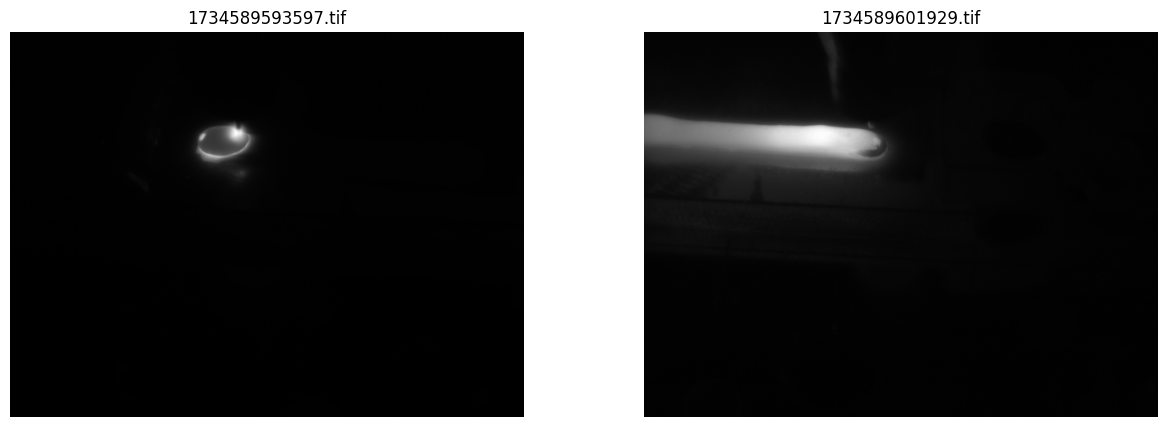

In [15]:
plot_random_images(test_dir,2)

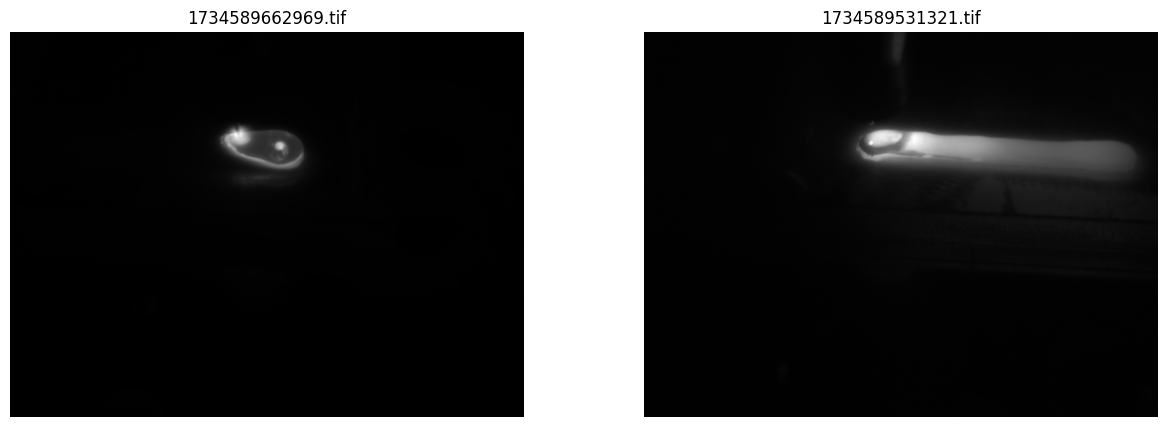

In [16]:
plot_random_images(train_dir,2)

# Selección del área de interés de las imágenes IR

Imagen seleccionada: 1734589671245.tif


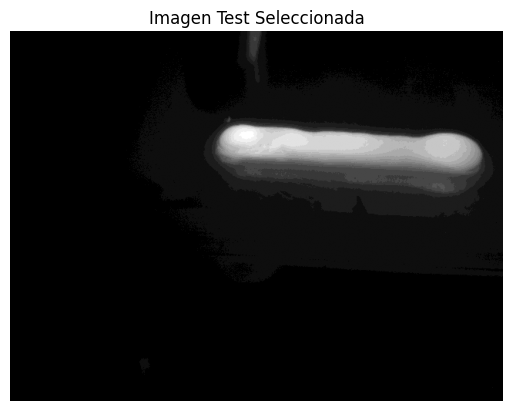

In [17]:
# Ruta del test
train_path = r'C:/MAESTRIA/CLASEIII_FINAL/Dataset/Ej3/train'

# Obtener lista de imágenes
train_images = [f for f in os.listdir(train_path) if f.endswith(('.jpg','.png','.tif'))]

# Seleccionar una al azar
random_image_name = random.choice(train_images)
random_image_path = os.path.join(train_path, random_image_name)

print("Imagen seleccionada:", random_image_name)

# Leer imagen
img_tr = cv2.imread(random_image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img_tr, cmap='gray')
plt.title("Imagen Test Seleccionada")
plt.axis('off')
plt.show()

Imagen seleccionada: 1734589665598.tif


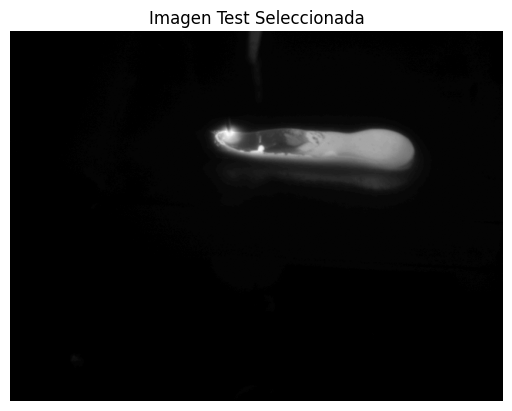

In [46]:
# Ruta del test
test_path = r'C:/MAESTRIA/CLASE III/Dataset/Ej3/test'

# Obtener lista de imágenes
test_images = [f for f in os.listdir(test_path) if f.endswith(('.jpg','.png','.tif'))]

# Seleccionar una al azar
random_image_name = random.choice(test_images)
random_image_path = os.path.join(test_path, random_image_name)

print("Imagen seleccionada:", random_image_name)

# Leer imagen
img_ts = cv2.imread(random_image_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img_ts, cmap='gray')
plt.title("Imagen Test Seleccionada")
plt.axis('off')
plt.show()

## Clustering

In [48]:
dataset_path = r'C:/MAESTRIA/CLASE III/Dataset'
train_dir = os.path.join(dataset_path, 'C:/MAESTRIA/CLASE III/Dataset/Ej3/train')

images = os.listdir(train_dir)
n_clusters = 3
all_pixels = []

for file_name in images:
    img_path = os.path.join(train_dir, file_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    all_pixels.append(img.flatten())

all_pixels.append(img_tr.flatten())

pixel_values = np.concatenate(all_pixels).reshape((-1,1)) # aplano la imagen
pixel_values = np.float32(pixel_values) # convierto a float32

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_values, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = centers.flatten()
labels = labels.flatten()

for i in range (n_clusters):
    cluster_pixels = pixel_values[labels == i] # si el cluster de etiqueta i, le corresponde a un pixel del vector
    if cluster_pixels.size > 0:
        c_min = np.min(cluster_pixels)
        c_max = np.max(cluster_pixels)
        c_center =  centers[i]
        print(f"Cluster: {i:<10} | Centros: {c_center:<10.2f} | Min: {c_min:<8.0f} | Max: {c_max:<8.0f}")

Cluster: 0          | Centros: 11.09      | Min: 7        | Max: 18      
Cluster: 1          | Centros: 1.24       | Min: 0        | Max: 6       
Cluster: 2          | Centros: 25.19      | Min: 19       | Max: 254     


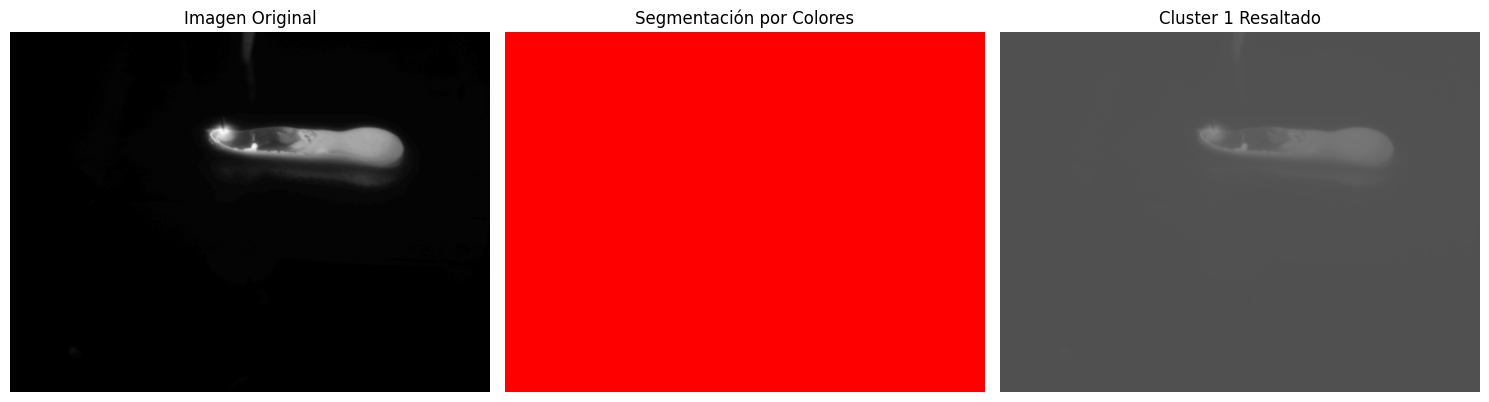

In [49]:
def apply_fixed_clusters(img, centros, target_cluster=None):
    centers = np.array(np.sort(centros), dtype=np.float32)
    pixel_values = img.astype(np.float32)
    distances = np.abs(pixel_values[:, :, np.newaxis] - centers)
    labels = np.argmin(distances, axis=2)

    colors = [
        [255, 0, 0],    # Cluster 0: Azul
        [0, 255, 0],    # Cluster 1: Verde
        [0, 0, 255],    # Cluster 2: Rojo
        [255, 255, 0],  # Cluster 3: Cyan
        [255, 0, 255],  # Cluster 4: Magenta
        [0, 255, 255],  # Cluster 5: Amarillo
        [255, 255, 255] # Cluster 6: Blanco
    ]
    
    h, w = img.shape
    colored_img = np.zeros((h, w, 3), dtype=np.uint8)
    
    for i in range(len(centers)):
        colored_img[labels == i] = colors[i]

    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Imagen Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
    plt.title("Segmentación por Colores")
    plt.axis('off')

    if target_cluster is not None:
        # Resaltar solo el cluster elegido sobre la imagen gris
        highlight = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        highlight[labels == target_cluster] = [0, 255, 0] # Verde brillante
        
        plt.subplot(1, 3, 3)
        plt.imshow(highlight)
        plt.title(f"Cluster {target_cluster} Resaltado")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

apply_fixed_clusters(img_ts, centers, target_cluster=1)

Valor agregado, segmentacion por 7 niveles de color

Rango de la imagen: Min=80, Max=137


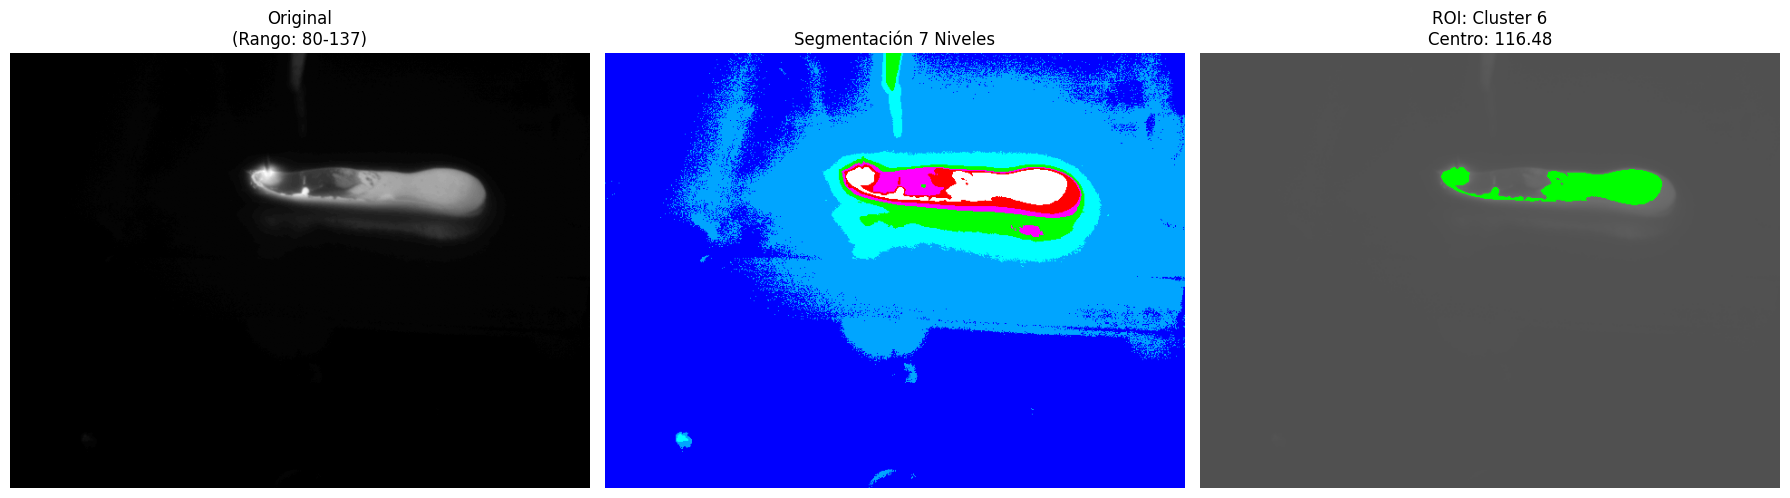

In [50]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

def apply_auto_clusters(img, n_clusters=7, target_cluster=None):
    # 1. Diagnóstico de la imagen
    img_min, img_max = img.min(), img.max()
    print(f"Rango de la imagen: Min={img_min}, Max={img_max}")

    # 2. AUTO-AJUSTE: Calculamos centros específicos para ESTA imagen
    # Esto asegura que los 7 colores se distribuyan en el rango real de la foto
    pixel_values = img.flatten().astype(np.float32).reshape((-1, 1))
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixel_values, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # Ordenar centros de menor (frío) a mayor (caliente)
    centers = np.sort(centers.flatten())
    
    # Re-asignar etiquetas basadas en centros ordenados
    distances = np.abs(img.astype(np.float32)[:, :, np.newaxis] - centers)
    labels = np.argmin(distances, axis=2)

    # 3. Definición de colores (RGB)
    colors = [
        [0, 0, 255],    # Cluster 0: Azul (Frío)
        [0, 165, 255],  # Cluster 1: Naranja claro
        [0, 255, 255],  # Cluster 2: Amarillo
        [0, 255, 0],    # Cluster 3: Verde
        [255, 0, 255],  # Cluster 4: Magenta
        [255, 0, 0],    # Cluster 5: Rojo
        [255, 255, 255] # Cluster 6: Blanco (Caliente)
    ]
    
    h, w = img.shape
    colored_img = np.zeros((h, w, 3), dtype=np.uint8)
    
    for i in range(len(centers)):
        colored_img[labels == i] = colors[i]

    # 4. Visualización
    plt.figure(figsize=(18, 6))
    
    # Panel 1: Original
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Original\n(Rango: {img_min}-{img_max})")
    plt.axis('off')

    # Panel 2: Segmentación completa
    plt.subplot(1, 3, 2)
    plt.imshow(colored_img) # Ya está en RGB
    plt.title(f"Segmentación {n_clusters} Niveles")
    plt.axis('off')

    # Panel 3: Resaltado de interés
    if target_cluster is not None:
        # Si el target es muy alto, lo ajustamos al máximo disponible
        target_cluster = min(target_cluster, n_clusters - 1)
        
        highlight = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        highlight[labels == target_cluster] = [0, 255, 0] # Verde neón para resaltar
        
        plt.subplot(1, 3, 3)
        plt.imshow(highlight)
        plt.title(f"ROI: Cluster {target_cluster}\nCentro: {centers[target_cluster]:.2f}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecución (Prueba con el cluster más alto, que suele ser el interés en IR)
apply_auto_clusters(img_ts, n_clusters=7, target_cluster=6)

# Técnica basada en FILTROS

In [51]:
def train_threshold(train_dir):
    thresholds = []

    for file in os.listdir(train_dir):
        img = cv2.imread(os.path.join(train_dir, file),
                         cv2.IMREAD_GRAYSCALE)
        blurred = cv2.GaussianBlur(img, (5,5), 0)
        
        t, _ = cv2.threshold(blurred, 0, 255,
                             cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thresholds.append(t)

    return np.mean(thresholds)

train_dir = os.path.join(dataset_path, 'Ej3/train')
train_threshold(train_dir)

np.float64(88.29856115107914)

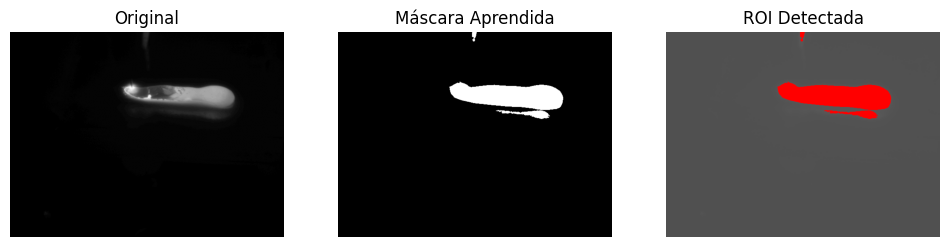

In [52]:
def apply_threshold_model(img, learned_threshold):
    _, mask = cv2.threshold(img, learned_threshold, 255,
                            cv2.THRESH_BINARY)

    colored = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # ROI en rojo
    colored[mask == 255] = [0, 0, 255]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Máscara Aprendida")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(colored, cv2.COLOR_BGR2RGB))
    plt.title("ROI Detectada")
    plt.axis('off')

    plt.show()
    
apply_threshold_model(img_ts, 88.29856115107914)

# Técnica basada en Bordes (CANNY)

In [53]:
def train_canny_params(train_dir):
    low_vals = []
    high_vals = []

    for file in os.listdir(train_dir):
        img = cv2.imread(os.path.join(train_dir, file),
                         cv2.IMREAD_GRAYSCALE)

        median = np.median(img)
        low = int(0.66 * median)
        high = int(1.33 * median)

        low_vals.append(low)
        high_vals.append(high)

    return int(np.mean(low_vals)), int(np.mean(high_vals))

train_dir = os.path.join(dataset_path, 'Ej3/train')
train_canny_params(train_dir)

(51, 105)

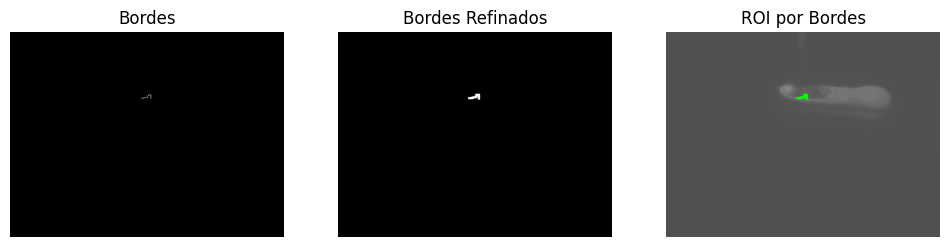

In [54]:
def apply_canny_model(img, low, high):
    edges = cv2.Canny(img, low, high)

    kernel = np.ones((3,3), np.uint8)
    closed = cv2.dilate(edges, kernel, iterations=2)

    colored = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # Bordes en verde
    colored[closed == 255] = [0,255,0]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(edges, cmap='gray')
    plt.title("Bordes")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(closed, cmap='gray')
    plt.title("Bordes Refinados")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(colored, cv2.COLOR_BGR2RGB))
    plt.title("ROI por Bordes")
    plt.axis('off')

    plt.show()

apply_canny_model(img_ts, 51, 105)

# Técnica basada en MORFOLOGÍA + K-Means

In [56]:
def train_kmeans_model(train_dir, n_clusters=3):
    all_pixels = []

    for file in os.listdir(train_dir):
        img = cv2.imread(os.path.join(train_dir, file),
                         cv2.IMREAD_GRAYSCALE)
        all_pixels.append(img.flatten())

    pixel_values = np.concatenate(all_pixels).reshape((-1,1))
    pixel_values = np.float32(pixel_values)

    criteria = (cv2.TERM_CRITERIA_EPS +
                cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

    _, labels, centers = cv2.kmeans(pixel_values,
                                    n_clusters,
                                    None,
                                    criteria,
                                    10,
                                    cv2.KMEANS_RANDOM_CENTERS)

    centers = centers.flatten()
    target_cluster = np.argmax(centers)  # más caliente

    return centers, target_cluster

train_dir = os.path.join(dataset_path, 'Ej3/train')
train_kmeans_model(train_dir, n_clusters=5)

(array([19.3638   ,  0.9906506, 25.280582 ,  5.453726 , 12.714905 ],
       dtype=float32),
 np.int64(2))

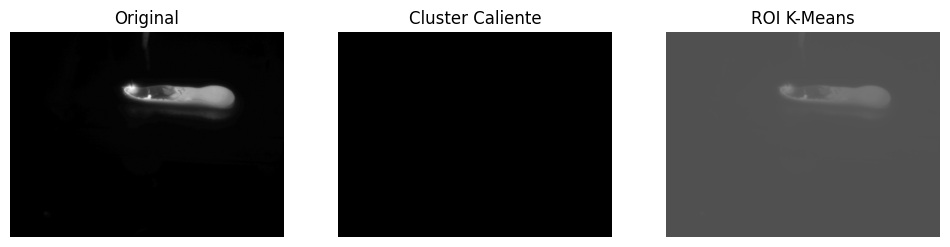

In [57]:
def apply_kmeans_roi(img, centers, target_cluster):
    centers = np.array(centers, dtype=np.float32)

    pixel_values = img.astype(np.float32)
    distances = np.abs(pixel_values[:, :, np.newaxis] - centers)
    labels = np.argmin(distances, axis=2)

    mask = np.zeros_like(img)
    mask[labels == target_cluster] = 255

    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    colored = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # ROI caliente en azul
    colored[mask == 255] = [255,0,0]

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Cluster Caliente")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(colored, cv2.COLOR_BGR2RGB))
    plt.title("ROI K-Means")
    plt.axis('off')

    plt.show()

apply_kmeans_roi(img_ts, centers, target_cluster=3)

# Comparacion

In [23]:
# MÉTRICAS NO SUPERVISADAS
def compute_unsupervised_metrics(img, mask):
    binary = mask > 0
    # Área total segmentada
    segmented_area = np.sum(binary)
    # Componentes conexos
    num_labels, labels = cv2.connectedComponents(mask)
    # Número real de regiones (sin fondo)
    num_regions = num_labels - 1
    # Área promedio por región
    region_sizes = []
    for i in range(1, num_labels):
        region_sizes.append(np.sum(labels == i))
    avg_region_area = np.mean(region_sizes) if region_sizes else 0
    # Contraste térmico
    if segmented_area > 0:
        roi_mean = np.mean(img[binary])
        background_mean = np.mean(img[~binary])
        contrast = roi_mean - background_mean
        roi_variance = np.var(img[binary])
    else:
        contrast = 0
        roi_variance = 0

    # Compacidad promedio
    compactness_list = []
    contours, _ = cv2.findContours(mask,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        if area > 0:
            compactness = (perimeter**2) / (4*np.pi*area)
            compactness_list.append(compactness)

    avg_compactness = np.mean(compactness_list) if compactness_list else 0
    return segmented_area, num_regions, avg_region_area, contrast, roi_variance, avg_compactness


# MÉTODOS DE SEGMENTACIÓN
def method_threshold(img, learned_threshold):
    _, mask = cv2.threshold(img, learned_threshold, 255, cv2.THRESH_BINARY)
    return mask

def method_edges(img, low, high):
    edges = cv2.Canny(img, low, high)
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.dilate(edges, kernel, iterations=2)
    return mask

def method_kmeans(img, centers, target_cluster):
    centers = np.array(centers, dtype=np.float32)
    pixel_values = img.astype(np.float32)
    distances = np.abs(pixel_values[:, :, np.newaxis] - centers)
    labels = np.argmin(distances, axis=2)
    mask = np.zeros_like(img)
    mask[labels == target_cluster] = 255
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

# EVALUACIÓN GLOBAL
def evaluate_methods(test_dir,
                     learned_threshold,
                     canny_low, canny_high,
                     centers, target_cluster):
    results = []
    for file in os.listdir(test_dir):
        img_path = os.path.join(test_dir, file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        # -------- Threshold
        start = time.time()
        mask1 = method_threshold(img, learned_threshold)
        t1 = time.time() - start
        m1 = compute_unsupervised_metrics(img, mask1)
        # -------- Edges
        start = time.time()
        mask2 = method_edges(img, canny_low, canny_high)
        t2 = time.time() - start
        m2 = compute_unsupervised_metrics(img, mask2)
        # -------- KMeans
        start = time.time()
        mask3 = method_kmeans(img, centers, target_cluster)
        t3 = time.time() - start
        m3 = compute_unsupervised_metrics(img, mask3)
        results.append([file, "Threshold", *m1, t1])
        results.append([file, "Edges", *m2, t2])
        results.append([file, "KMeans", *m3, t3])

    columns = [
        "Image", "Method",
        "SegmentedArea",
        "NumRegions",
        "AvgRegionArea",
        "ThermalContrast",
        "ROIVariance",
        "AvgCompactness",
        "Time(s)"
    ]

    df = pd.DataFrame(results, columns=columns)
    return df

# EJECUCIÓN
test_dir = os.path.join(dataset_path, 'Ej3/train')

learned_threshold = 88.29856115107914
canny_low = 51
canny_high = 105
centers = [12.714905 ,  0.9906506,  5.453726 , 25.280582 , 19.3638]
target_cluster = 3

df_results = evaluate_methods(test_dir,
                              learned_threshold,
                              canny_low, canny_high,
                              centers, target_cluster)

print("\nResultados por imagen:")
print(df_results)

print("\nPromedio por método:")
print(df_results.groupby("Method").mean(numeric_only=True))

c:\Users\Danny\anaconda3\envs\tsi\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Danny\anaconda3\envs\tsi\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


KeyboardInterrupt: 

Ejercicio Numero 3, parte 2:

Una vez que haya podido elegir el área de interés úselo como una mascara para aplicar el conjunto de prueba (testset), donde solo se puede observar el área de interés y el resto de pixeles estén asignado el valor de cero 0

Procesando 70 imágenes...
¡Hecho! Las imágenes se guardaron en: C:/MAESTRIA/CLASE III/Dataset/Ej3/Resultado


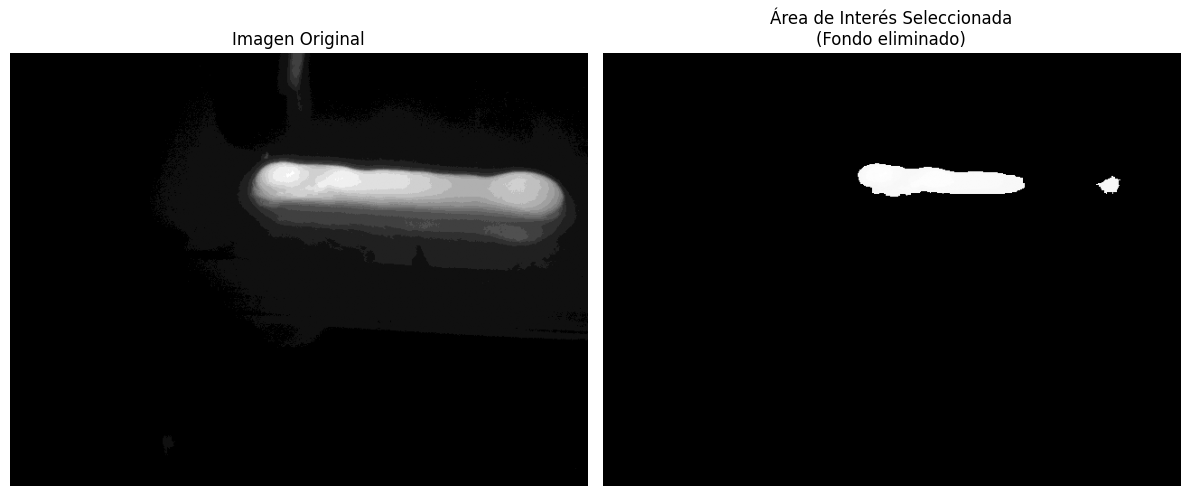

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE RUTAS ---
test_dir = r'C:/MAESTRIA/CLASE III/Dataset/Ej3/test'
output_dir = r'C:/MAESTRIA/CLASE III/Dataset/Ej3/Resultado'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

def apply_auto_roi_mask(img_path, n_clusters=7):
    """
    Lee una imagen, calcula sus propios centros de intensidad,
    genera una máscara para el área más brillante y la aplica.
    """
    # 1. Leer imagen en gris
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None, None
    
    # 2. Calcular K-means dinámico para esta imagen
    # Esto soluciona el problema de los centros fijos que no coinciden
    pixel_values = img.flatten().astype(np.float32).reshape((-1, 1))
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(pixel_values, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    # 3. Ordenar centros para saber cuál es el más brillante (el último)
    centers = centers.flatten()
    sorted_indices = np.argsort(centers) # Índices de menor a mayor
    brightest_cluster_idx = sorted_indices[-1] # El índice del centro con valor más alto
    
    # 4. Crear la máscara para el área de interés
    # Re-mapeamos las etiquetas para encontrar el cluster más brillante
    labels_reshaped = labels.reshape(img.shape)
    mask = np.zeros_like(img, dtype=np.uint8)
    mask[labels_reshaped == brightest_cluster_idx] = 255
    
    # 5. Limpieza morfológica (Cierre para rellenar huecos)
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # 6. Aplicar máscara: Solo queda el ROI, lo demás es CERO
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    
    return masked_img, img

# --- PROCESAMIENTO DEL TESTSET ---
test_files = [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.png', '.tif'))]
print(f"Procesando {len(test_files)} imágenes...")

last_orig, last_mask = None, None

for file in test_files:
    path = os.path.join(test_dir, file)
    roi_result, original = apply_auto_roi_mask(path)
    
    if roi_result is not None:
        # Guardar en la carpeta Resultado
        cv2.imwrite(os.path.join(output_dir, f"ROI_Masked_{file}"), roi_result)
        last_orig, last_mask = original, roi_result

print(f"¡Hecho! Las imágenes se guardaron en: {output_dir}")

# --- COMPARATIVA VISUAL ---
if last_mask is not None:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(last_orig, cmap='gray')
    plt.title("Imagen Original")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(last_mask, cmap='gray')
    plt.title("Área de Interés Seleccionada\n(Fondo eliminado)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Ejercicio Final 

Aplique la segmentación de imágenes con el algoritmo kmeans solo al área de interés del conjunto de entrenamiento (trainset) y encuentre los 3 o 4 clústers del área de interés y exporte su centro, valor máximo y mínimo.

In [ ]:
import os
import cv2
import numpy as np

def segment_roi_kmeans(train_dir, n_clusters=3):
    # 1. Calcular el Umbral Maestro (Otsu Promedio) para aislar el ROI
    thresholds = []
    valid_extensions = ('.jpg', '.png', '.tif', '.jpeg')
    files = [f for f in os.listdir(train_dir) if f.lower().endswith(valid_extensions)]
    
    print(f"Procesando {len(files)} imágenes para análisis de ROI...")

    for file in files:
        img = cv2.imread(os.path.join(train_dir, file), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        blurred = cv2.GaussianBlur(img, (5,5), 0)
        t, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thresholds.append(t)
    
    learned_threshold = np.mean(thresholds)
    print(f"-> Umbral de aislamiento ROI: {learned_threshold:.2f}")

    # 2. Extraer solo los píxeles que pertenecen al objeto (ROI)
    roi_pixels_list = []
    for file in files:
        img = cv2.imread(os.path.join(train_dir, file), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        
        # Crear máscara binaria
        _, mask = cv2.threshold(img, learned_threshold, 255, cv2.THRESH_BINARY)
        
        # Extraer píxeles donde la máscara es blanca
        pixels_in_roi = img[mask == 255]
        roi_pixels_list.append(pixels_in_roi)

    # 3. Preparar datos para K-Means
    # Concatenamos todos los píxeles de todas las ROIs en un solo vector gigante
    all_roi_pixels = np.concatenate(roi_pixels_list).reshape((-1, 1))
    all_roi_pixels = np.float32(all_roi_pixels)

    # 4. Aplicar K-Means sobre el ROI
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(all_roi_pixels, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Aplanar para facilitar cálculos
    centers = centers.flatten()
    labels = labels.flatten()

    # 5. Exportar y mostrar resultados
    print(f"\n--- ESTADÍSTICAS DE LOS {n_clusters} CLUSTERS EN EL ROI ---")
    print(f"{'Cluster':<10} | {'Centro':<10} | {'Mínimo':<8} | {'Máximo':<8}")
    print("-" * 50)
    
    for i in range(n_clusters):
        cluster_data = all_roi_pixels[labels == i]
        if cluster_data.size > 0:
            c_min = np.min(cluster_data)
            c_max = np.max(cluster_data)
            c_center = centers[i]
            print(f"{i:<10} | {c_center:<10.2f} | {c_min:<8.0f} | {c_max:<8.0f}")

# Ejecución del proceso
train_path = r'C:/MAESTRIA/CLASEIII_FINAL/Dataset/Ej3/train'
segment_roi_kmeans(train_path, n_clusters=3)

Procesando 278 imágenes para análisis de ROI...
-> Umbral de aislamiento ROI: 88.30

--- ESTADÍSTICAS DE LOS 3 CLUSTERS EN EL ROI ---
Cluster    | Centro     | Mínimo   | Máximo  
--------------------------------------------------
0          | 92.87      | 89       | 98      
1          | 117.97     | 111      | 254     
2          | 104.00     | 99       | 110     


Con los valores obtenidos de cada clúster, aplíquelos al conjunto de prueba (testset) y observe si su desarrollo se acopla a todas las imágenes.

Entrenando con 278 imágenes...
✓ Entrenamiento completado.
Parámetros Globales -> Umbral: 88.30 | Centros: [ 93.1314   105.14081  119.540344]
Evaluando 70 imágenes de prueba...



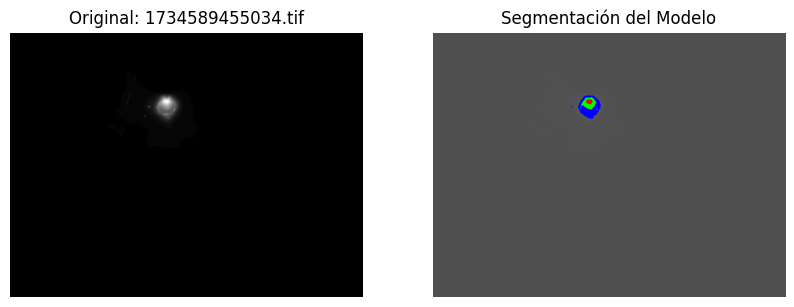

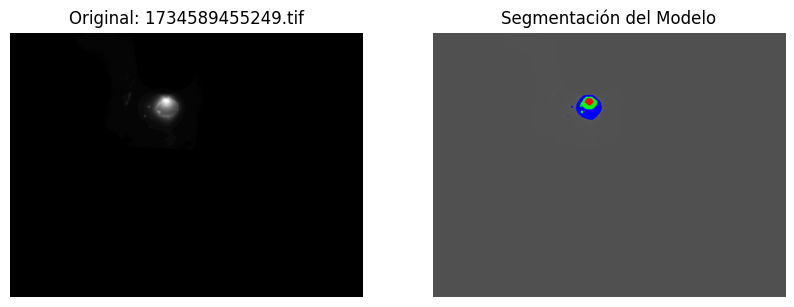

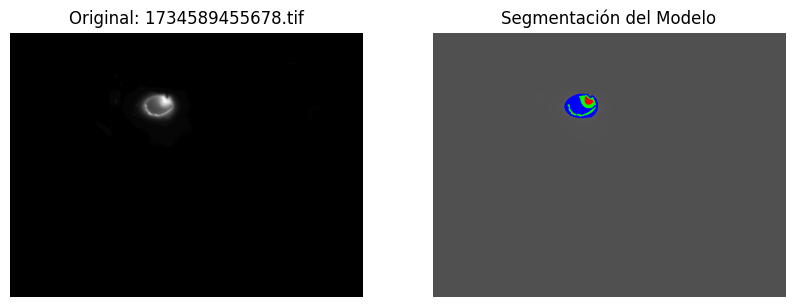

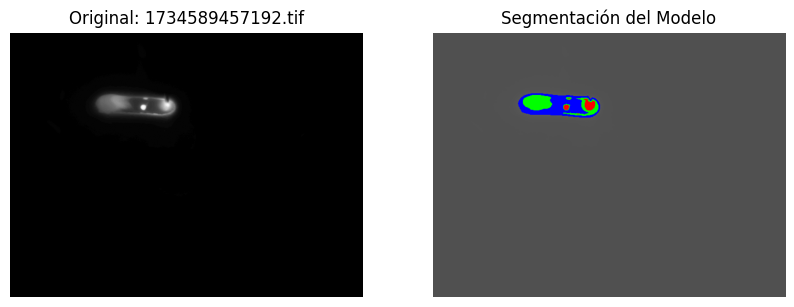

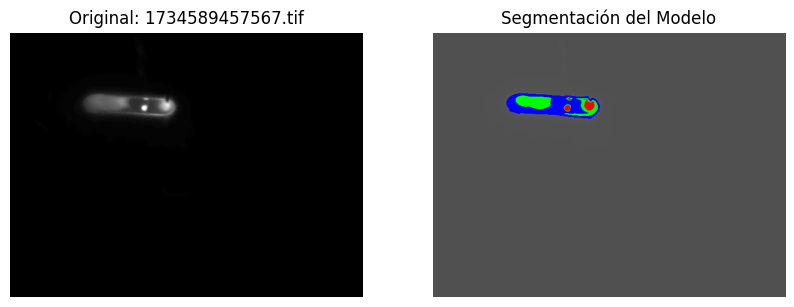

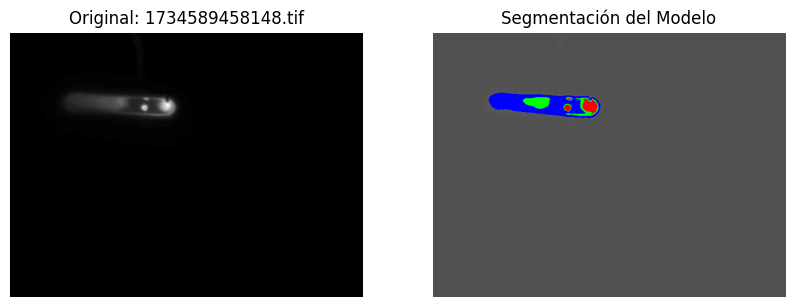

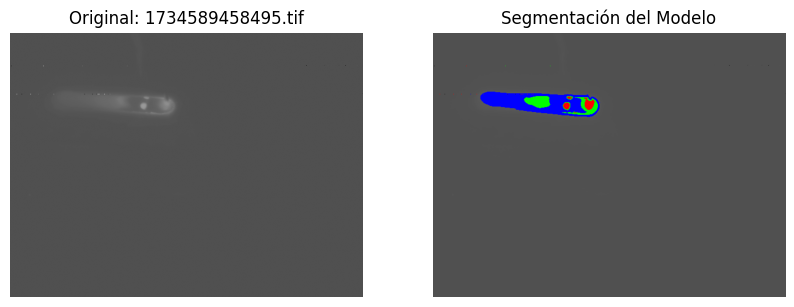

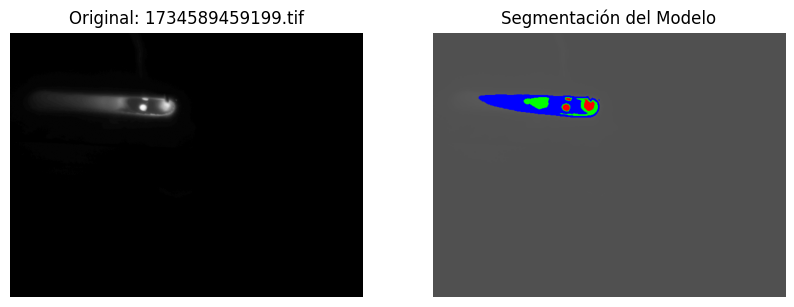

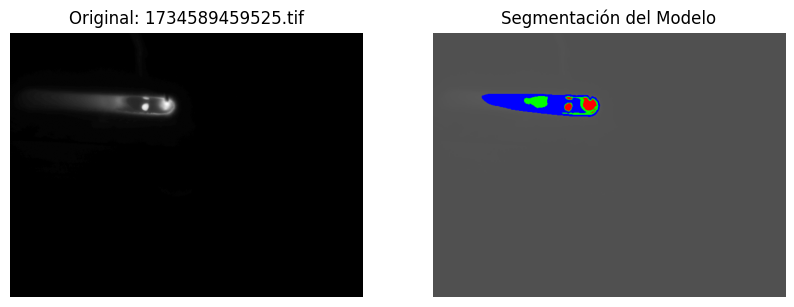

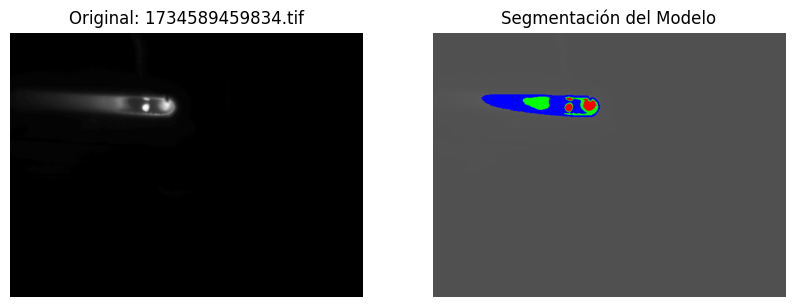

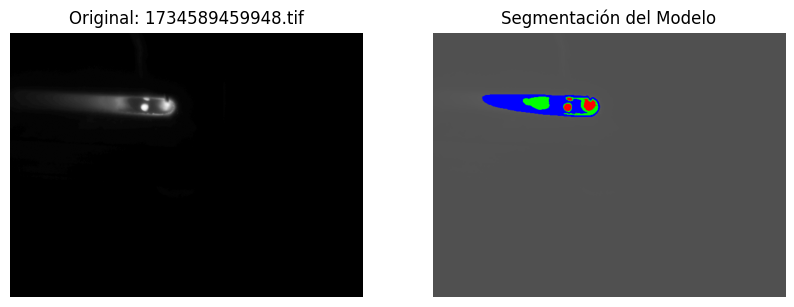

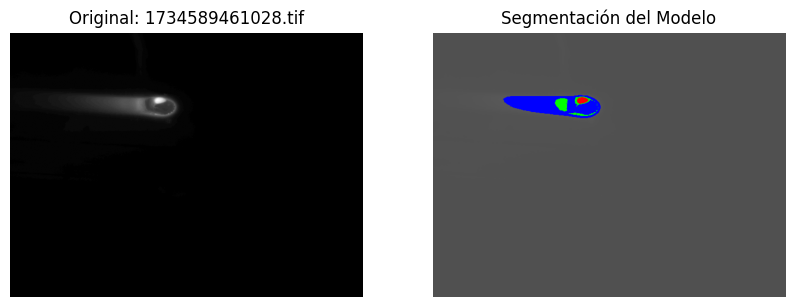

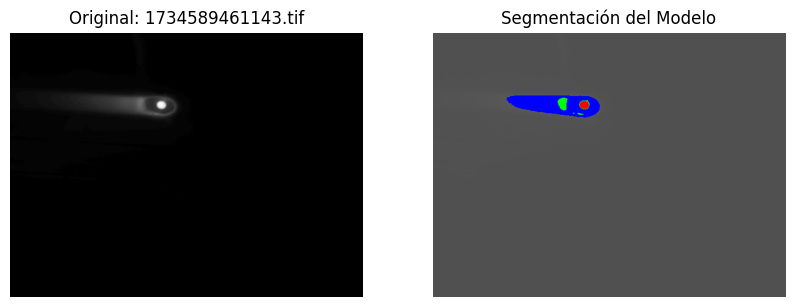

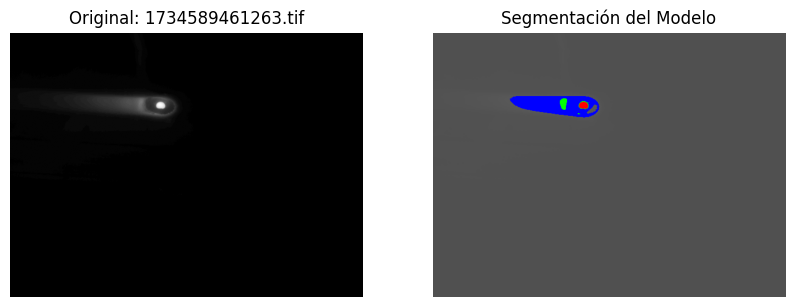

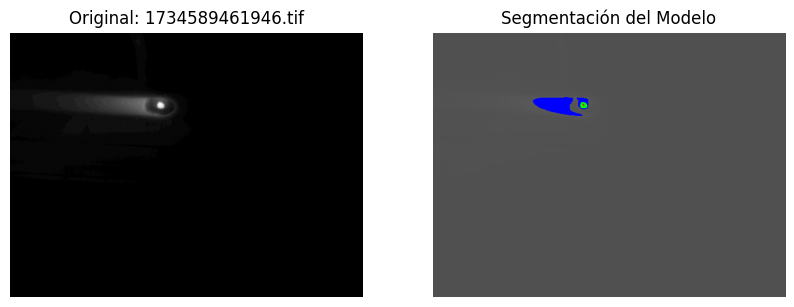

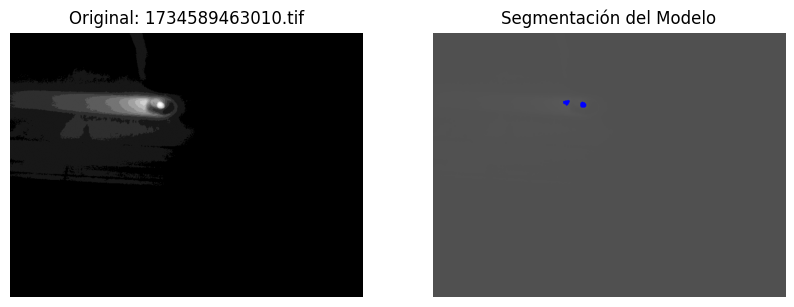

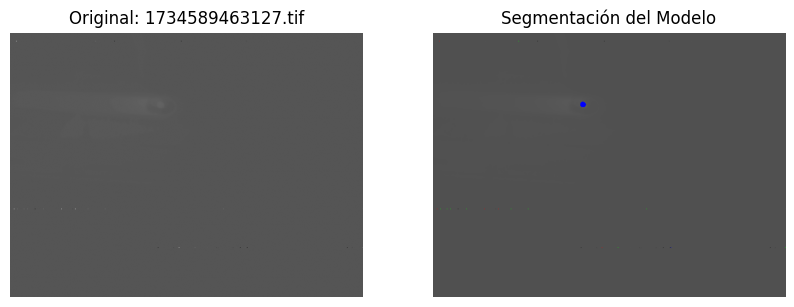

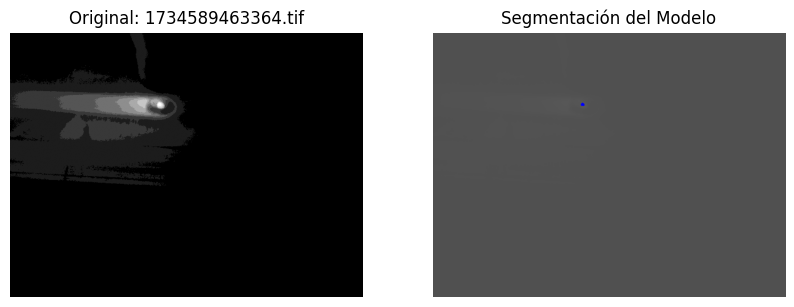

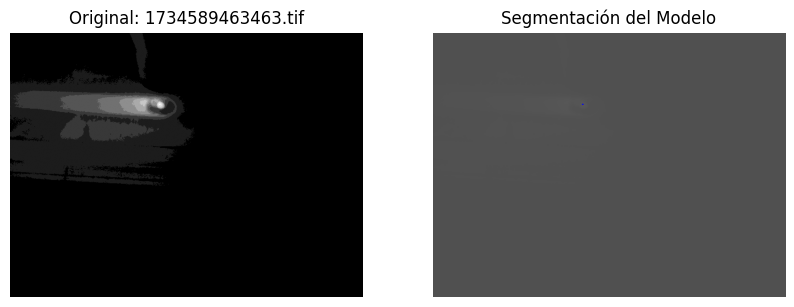

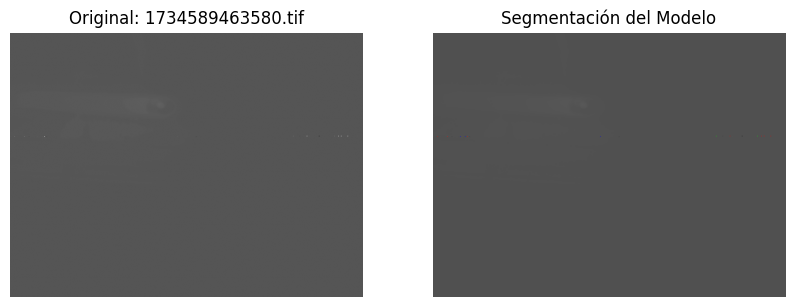

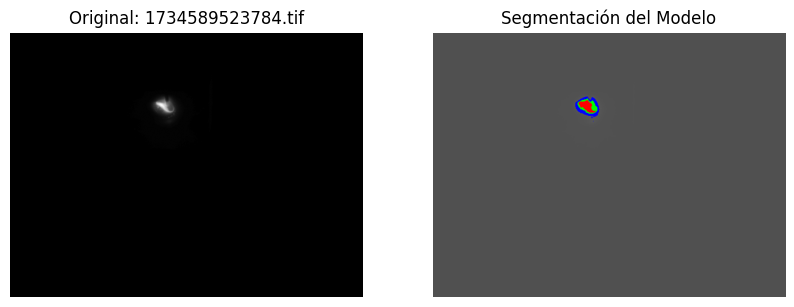

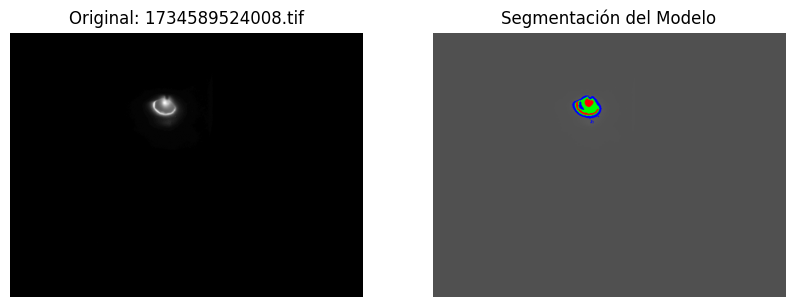

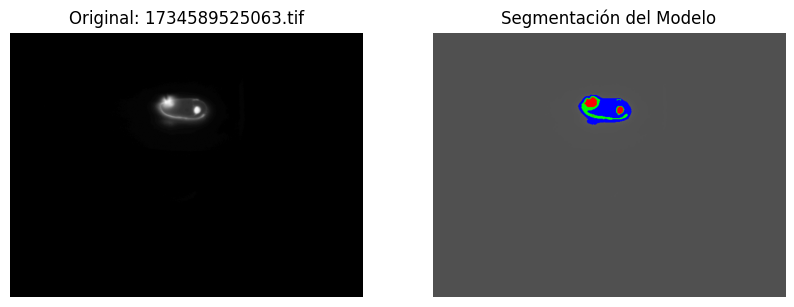

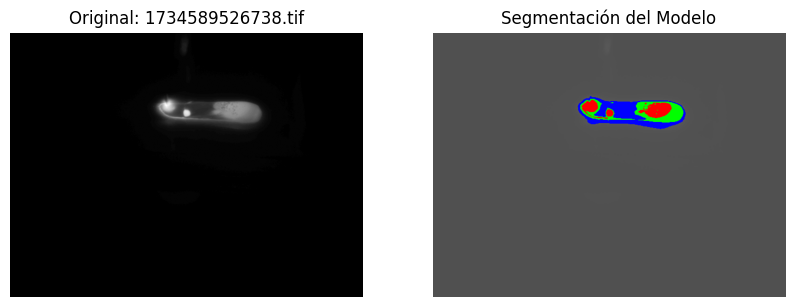

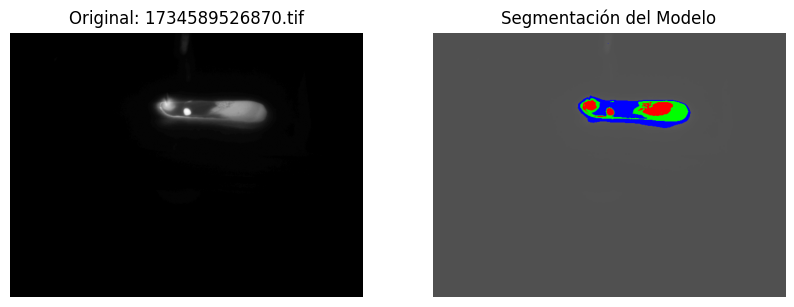

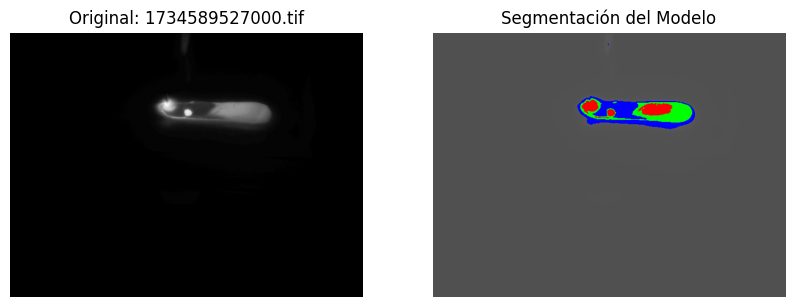

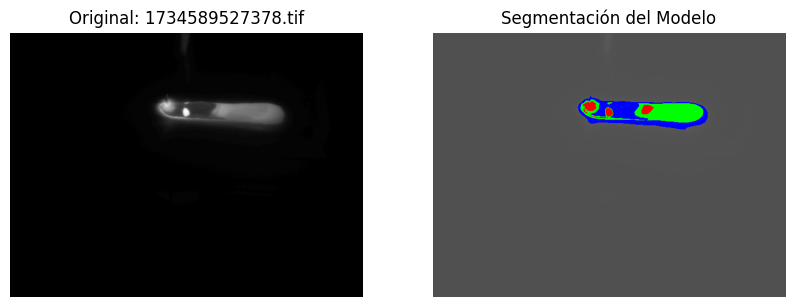

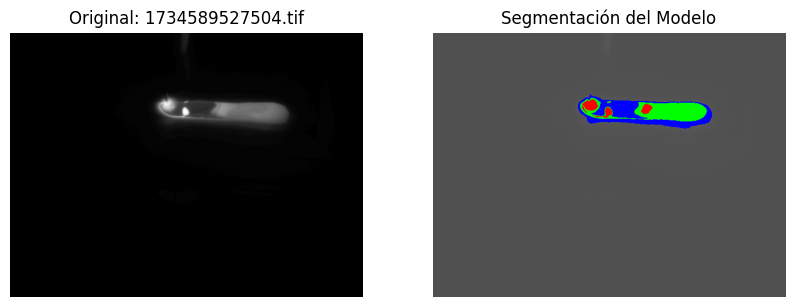

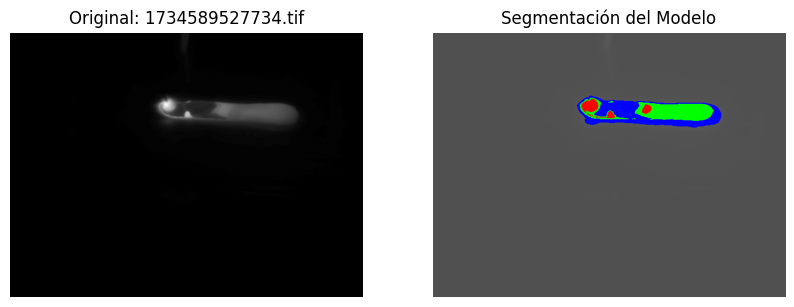

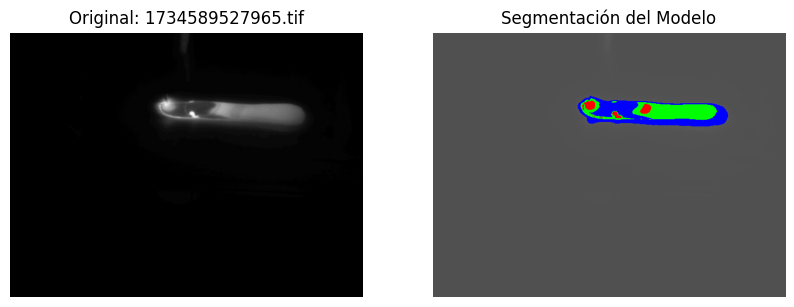

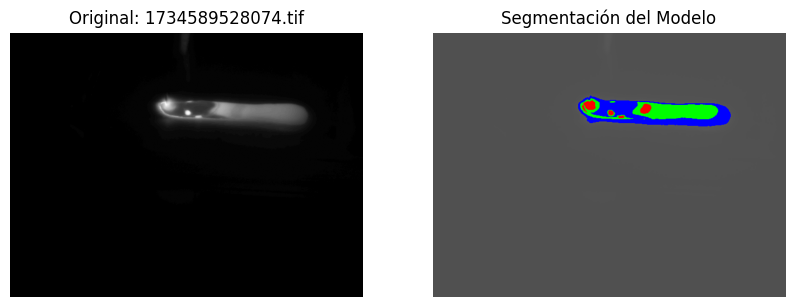

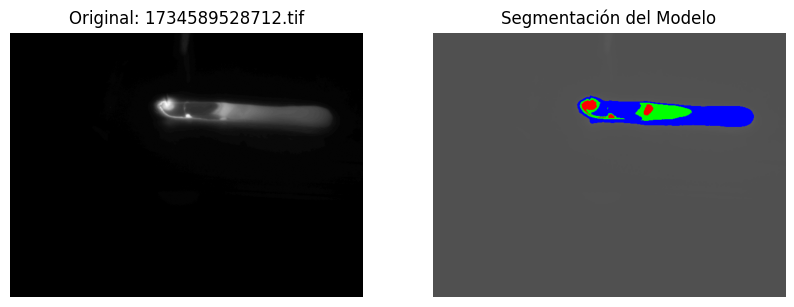

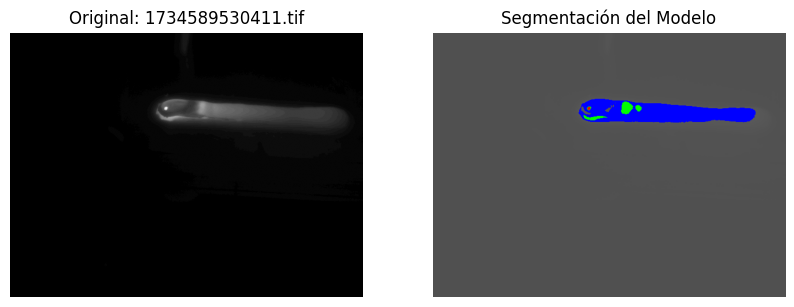

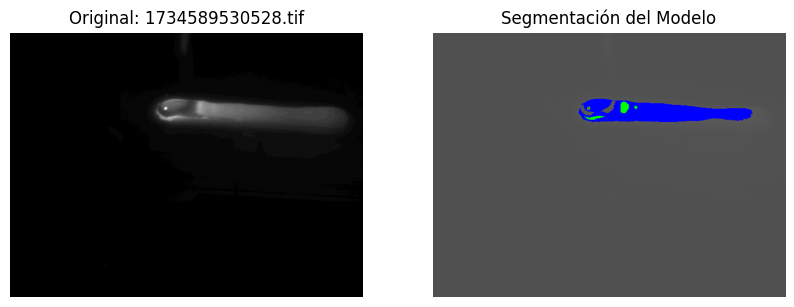

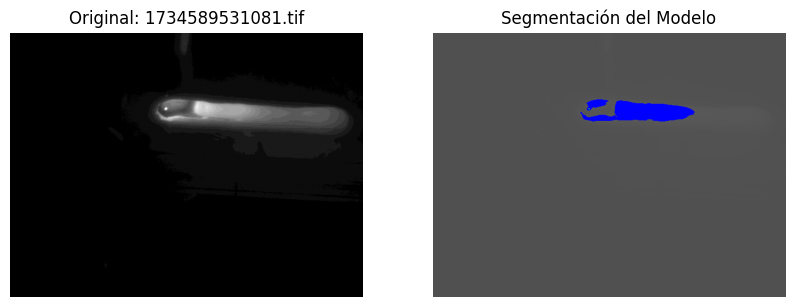

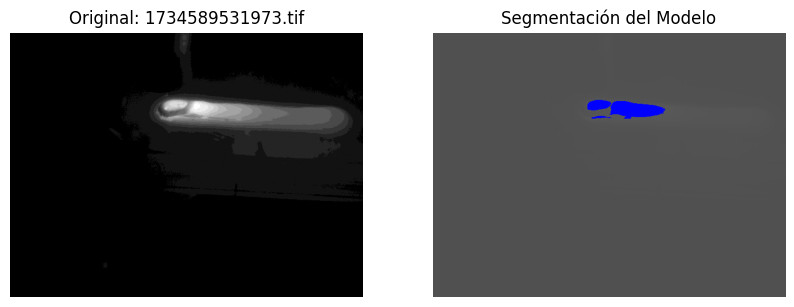

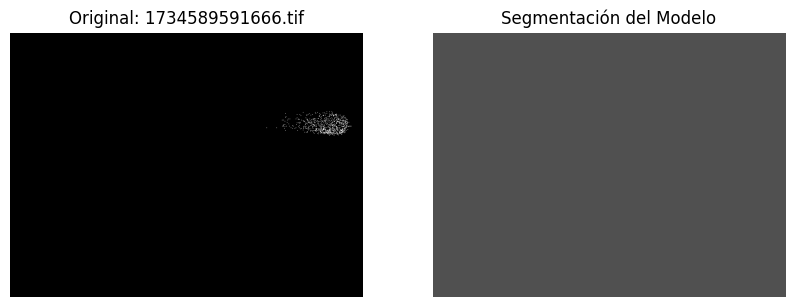

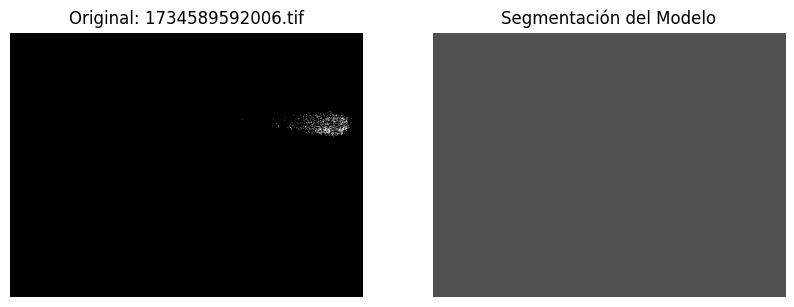

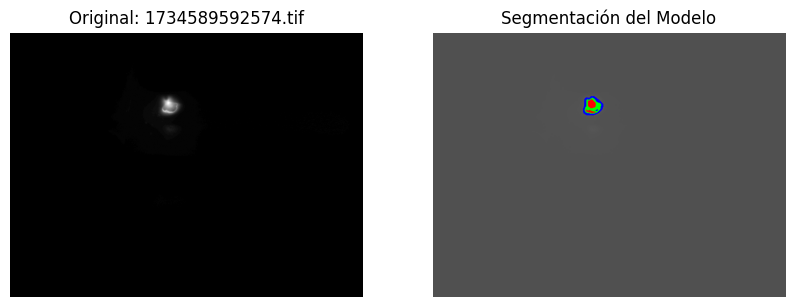

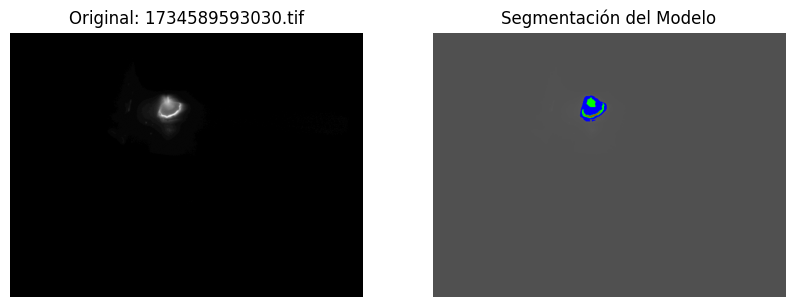

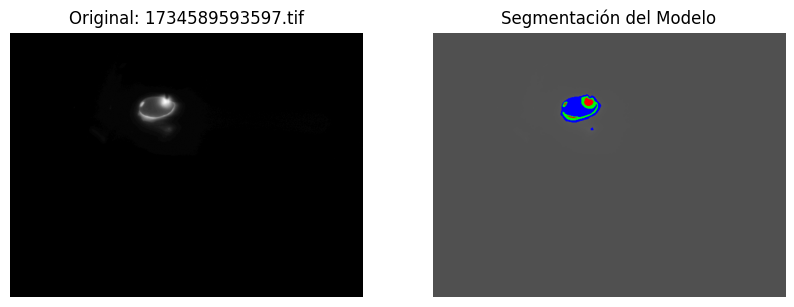

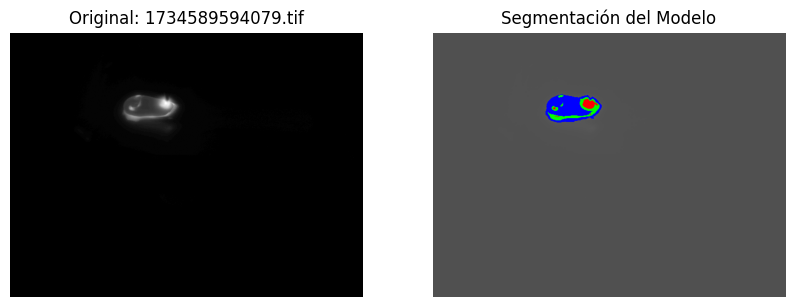

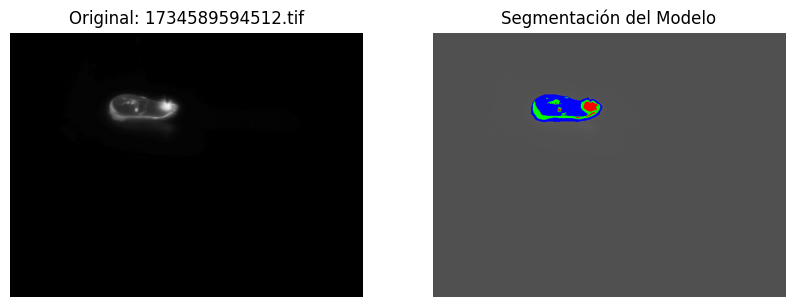

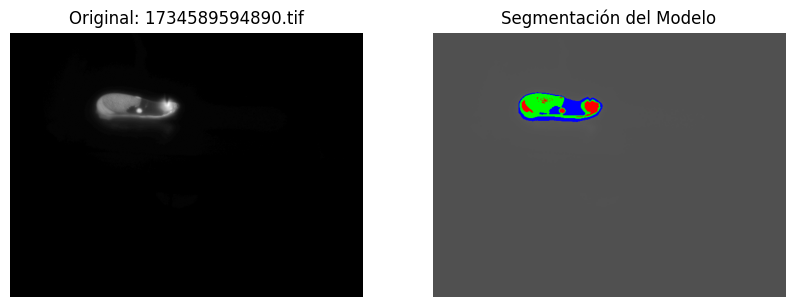

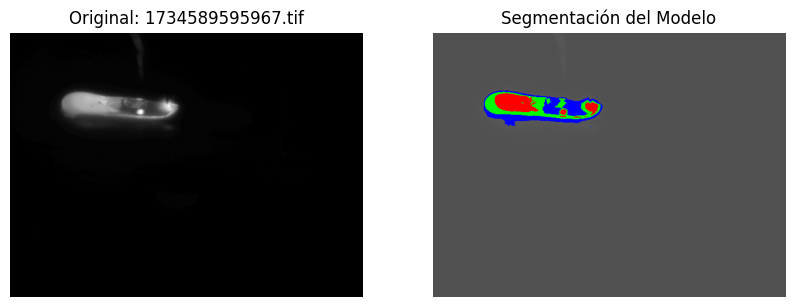

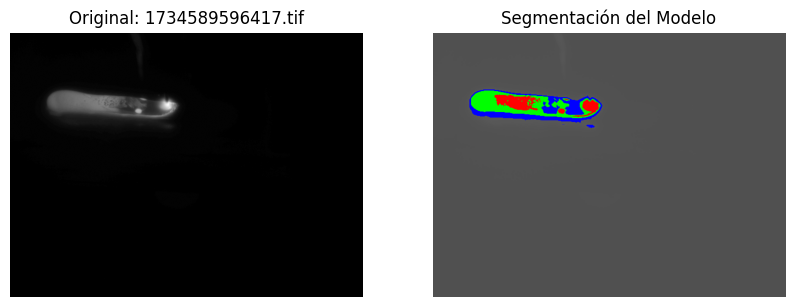

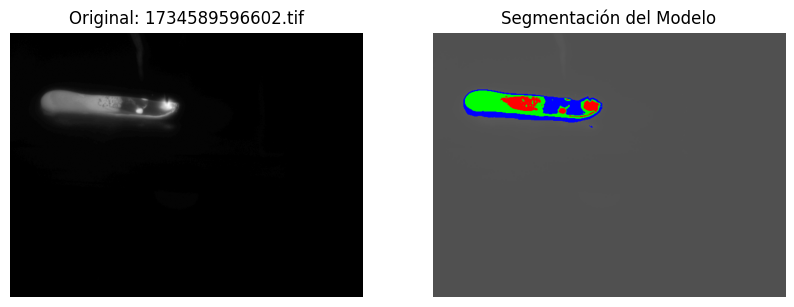

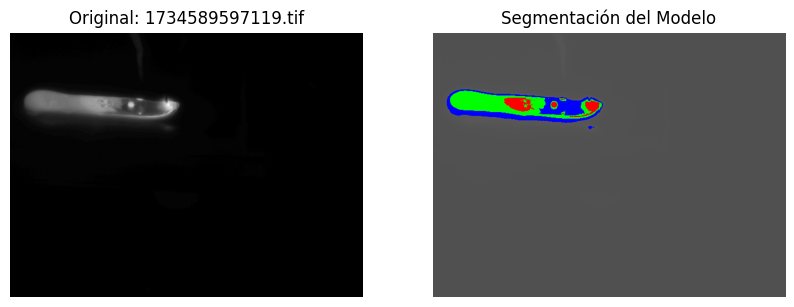

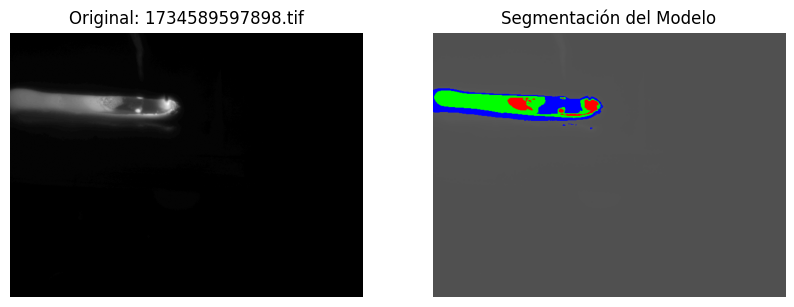

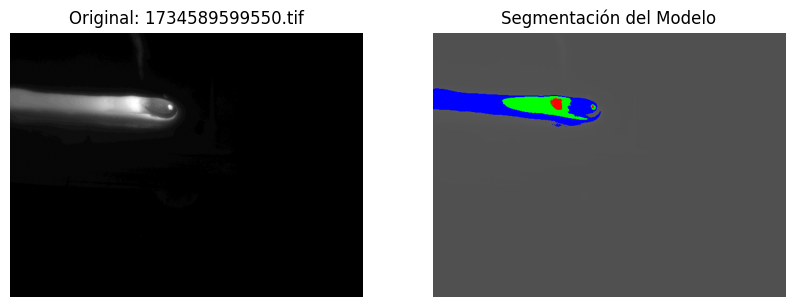

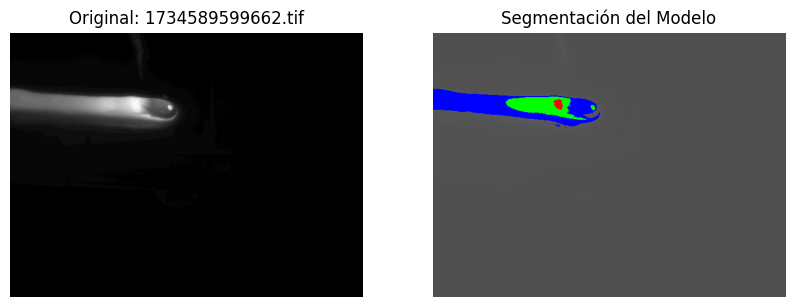

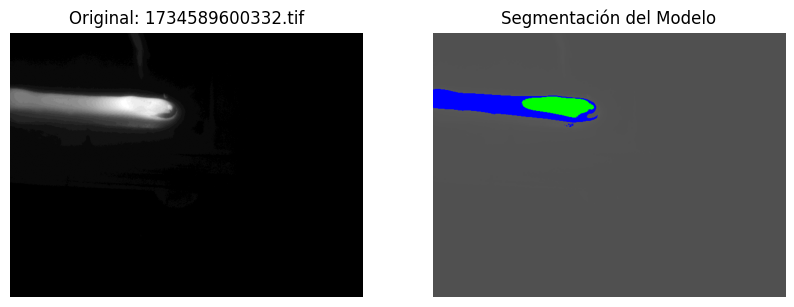

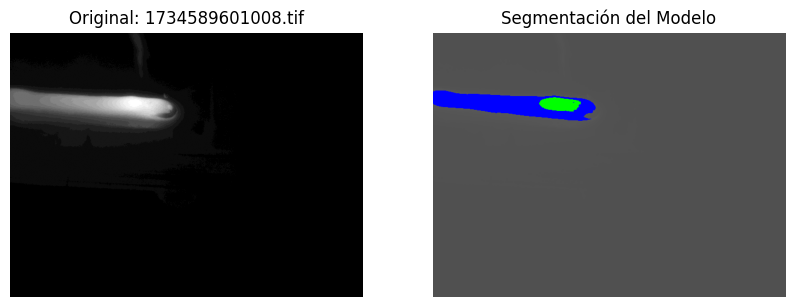

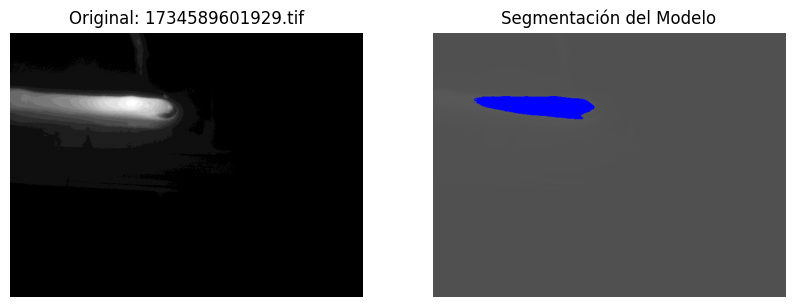

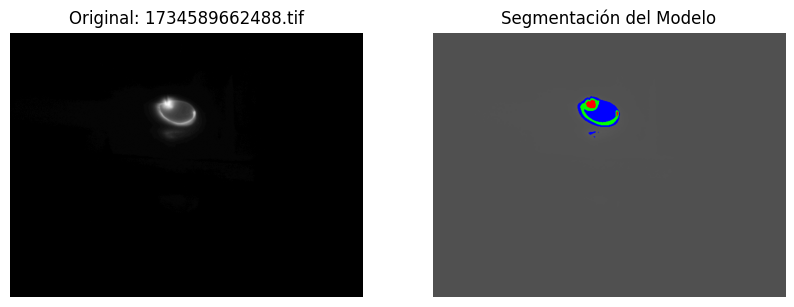

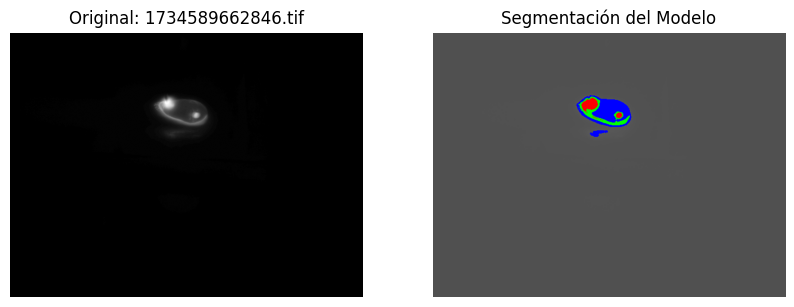

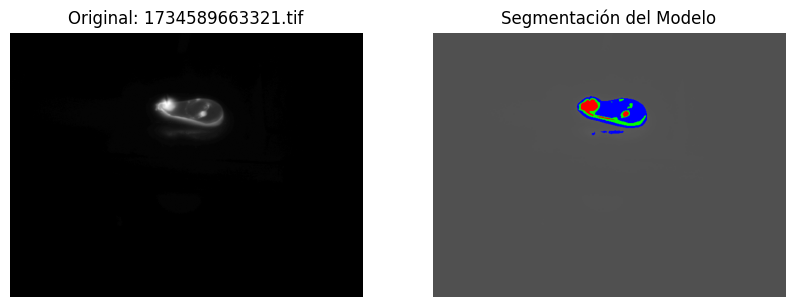

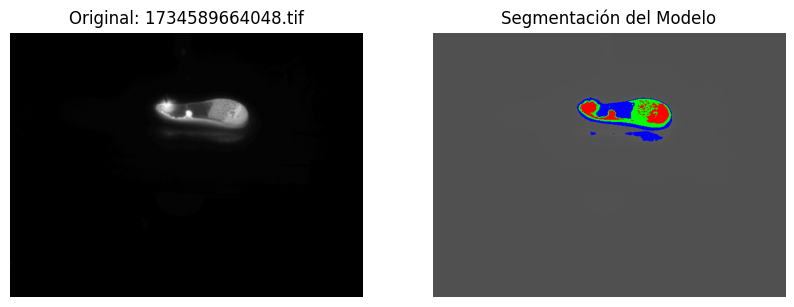

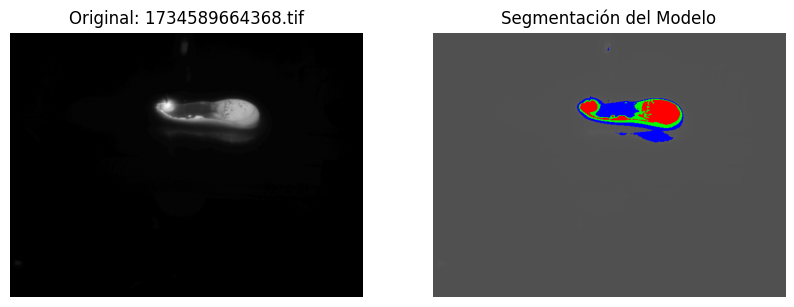

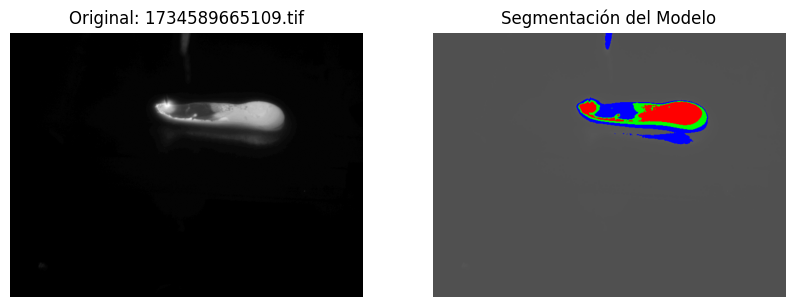

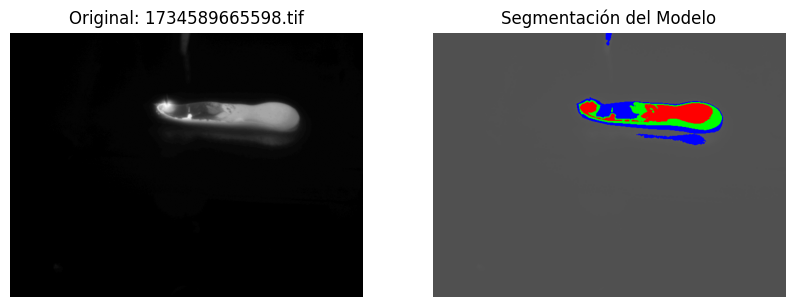

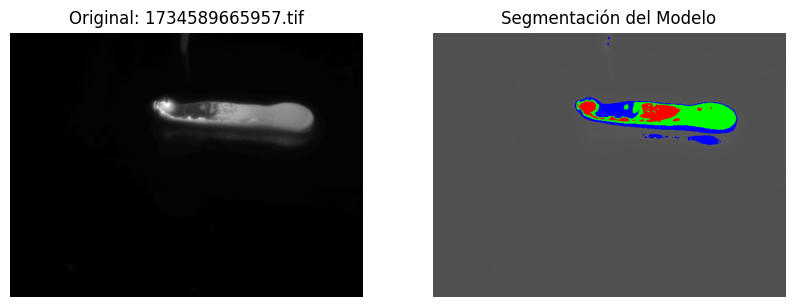

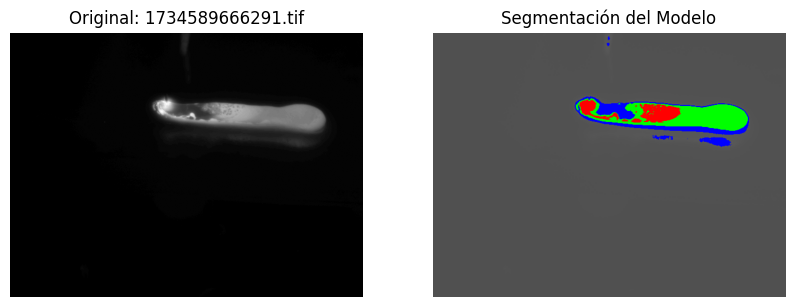

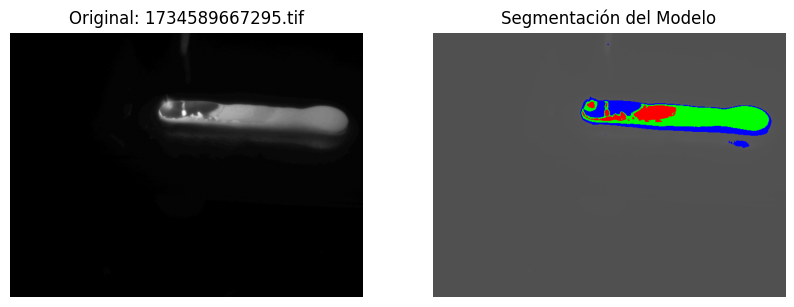

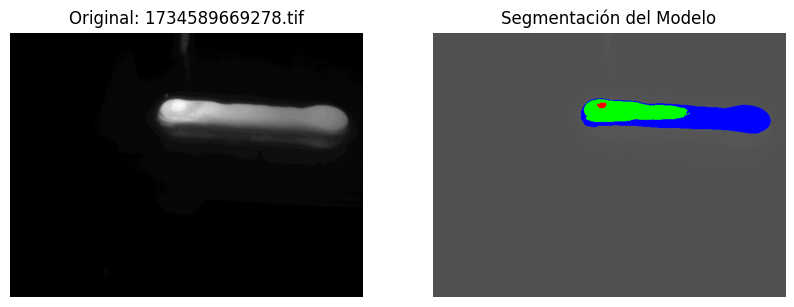

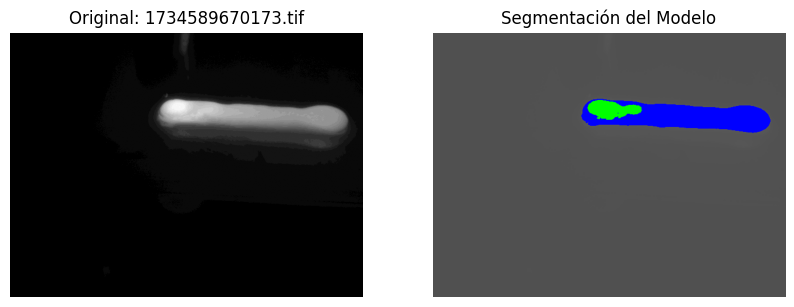

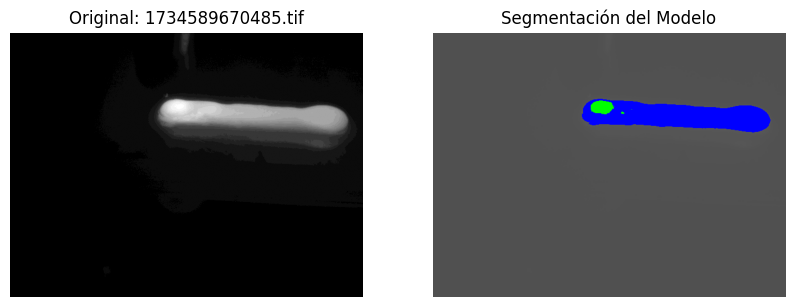

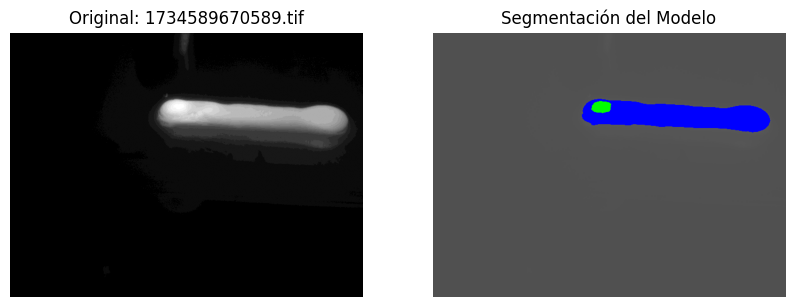

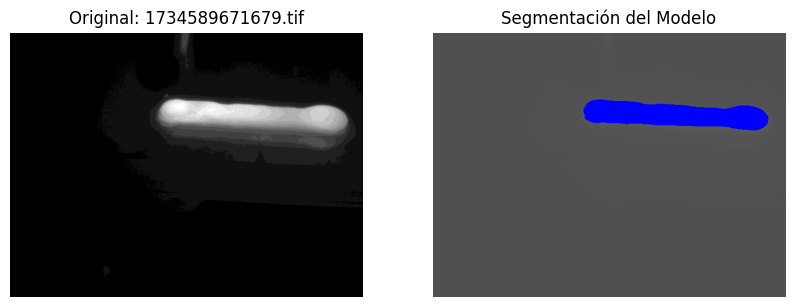

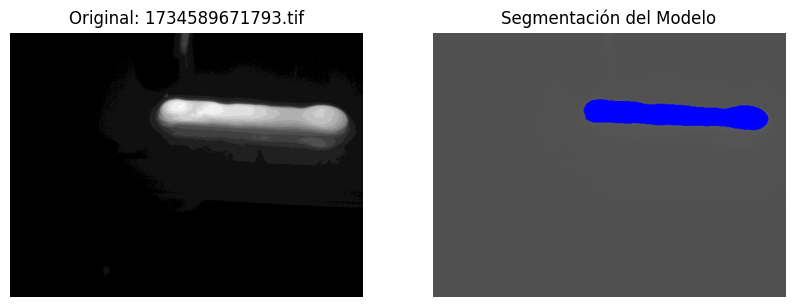

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS
# ==========================================
# Asegúrate de que estas rutas sean las correctas en tu PC
dataset_path = r'C:/MAESTRIA/CLASEIII_FINAL/Dataset'
train_dir = os.path.join(dataset_path, 'Ej3/train')
test_dir = os.path.join(dataset_path, 'Ej3/test')

# ==========================================
# 2. FUNCIÓN DE ENTRENAMIENTO
# ==========================================
def train_roi_model(train_path, n_clusters=3):
    """
    Analiza el set de entrenamiento para obtener el umbral maestro
    y los centros de intensidad (K-means) del objeto.
    """
    thresholds = []
    roi_pixels_list = []
    valid_extensions = ('.jpg', '.png', '.tif', '.jpeg')
    files = [f for f in os.listdir(train_path) if f.lower().endswith(valid_extensions)]
    
    if not files:
        raise FileNotFoundError(f"No se encontraron imágenes en {train_path}")

    print(f"Entrenando con {len(files)} imágenes...")

    # Paso A: Calcular Umbral Maestro Global (Otsu)
    for file in files:
        img = cv2.imread(os.path.join(train_path, file), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        blurred = cv2.GaussianBlur(img, (5,5), 0)
        t, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thresholds.append(t)
    
    learned_threshold = np.mean(thresholds)

    # Paso B: Extraer píxeles del ROI para K-means
    for file in files:
        img = cv2.imread(os.path.join(train_path, file), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        _, mask = cv2.threshold(img, learned_threshold, 255, cv2.THRESH_BINARY)
        roi_pixels_list.append(img[mask == 255])

    # Paso C: K-means sobre el ROI
    all_roi_pixels = np.concatenate(roi_pixels_list).reshape((-1, 1))
    all_roi_pixels = np.float32(all_roi_pixels)
    
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, _, centers = cv2.kmeans(all_roi_pixels, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Ordenamos centros de oscuro a claro para que los colores sean consistentes
    sorted_centers = np.sort(centers.flatten())
    
    print(f"✓ Entrenamiento completado.")
    return learned_threshold, sorted_centers

# ==========================================
# 3. FUNCIÓN DE PRUEBA Y VISUALIZACIÓN
# ==========================================
def apply_model_to_testset(test_path, learned_threshold, centers):
    """
    Aplica los parámetros aprendidos a las imágenes de prueba.
    """
    valid_extensions = ('.jpg', '.png', '.tif', '.jpeg')
    test_files = [f for f in os.listdir(test_path) if f.lower().endswith(valid_extensions)]
    
    # Definimos colores: Azul (Sombra), Verde (Medio), Rojo (Brillo)
    colors = [[255, 0, 0], [0, 255, 0], [0, 0, 255], [0, 255, 255]] 

    print(f"Evaluando {len(test_files)} imágenes de prueba...\n")

    for file_name in test_files:
        img = cv2.imread(os.path.join(test_path, file_name), cv2.IMREAD_GRAYSCALE)
        if img is None: continue

        # 1. Segmentar el objeto (ROI)
        _, mask = cv2.threshold(img, learned_threshold, 255, cv2.THRESH_BINARY)

        # 2. Clasificar intensidades según centros aprendidos
        pixel_values = img.astype(np.float32)
        distances = np.abs(pixel_values[:, :, np.newaxis] - centers)
        labels = np.argmin(distances, axis=2)

        # 3. Crear imagen de resultado con colores
        result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        for i in range(len(centers)):
            region_mask = (labels == i) & (mask == 255)
            result_img[region_mask] = colors[i % len(colors)]

        # 4. Mostrar en pantalla
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Original: {file_name}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
        plt.title("Segmentación del Modelo")
        plt.axis('off')
        plt.show()

# ==========================================
# 4. EJECUCIÓN DEL FLUJO COMPLETO
# ==========================================
try:
    # Capturamos los valores que devuelve el entrenamiento
    final_threshold, final_centers = train_roi_model(train_dir, n_clusters=3)
    
    print(f"Parámetros Globales -> Umbral: {final_threshold:.2f} | Centros: {final_centers}")
    
    # Pasamos esos valores a la función de prueba
    apply_model_to_testset(test_dir, final_threshold, final_centers)

except Exception as e:
    print(f"Error durante la ejecución: {e}")